In [1]:
from analytical import *
from electronic import *
from engine import *
from integrator import *
from selector import *
from trajectory import *
from path_sampling import *
import numpy as np

In [2]:
# Define the basin states

def in_stateA(q, s):
    return q<-0.8 and s == 0

def in_stateB(q, s):
    return q>0.8 and s == 0

In [3]:
# Generate seed trajectory for TPS

v_init = -0.05
q_init = 1.0
coeff_init = np.array([1.0, 0.0], dtype=complex)
mass = 1836.15
act_state_init = 0
dt = 5
max_steps = 10000

x0 = 1.0
k = 0.1
Vc = 0.4
eps = 0.05

SHO_H = DoubleHarmonic(k=2 * eps, x0=1.0, vc=Vc * eps)
C_init = SHO_H.eigvecs(q_init)

initial_snapshot = Snapshot(positions=q_init,
                            velocities=v_init,
                            coefficients=coeff_init,
                            active_state=act_state_init,
                            gauge=C_init,
                            mass=mass,
                            is_grid=True)

seedMASH = MASHEngine(model=SHO_H, dt=dt, initial_snapshot=initial_snapshot)

seed_traj = seedMASH.propagate_until_X(max_steps=max_steps, stateA=in_stateA, stateB=in_stateB)

In [ ]:
selector = UniformShootingSelector(temp=300.0, mass=1836.15, alpha=0.9, stateA_func=in_stateA, stateB_func=in_stateB)

path_sampling = PathSampling(selector=selector, seed_traj=seed_traj, max_iter=10000,
                             max_length=5000, in_stateA=in_stateA, in_stateB=in_stateB)

engine_builder = MASHEngine
tps_ensemble, naive_tps_ensemble = path_sampling.run(engine=engine_builder, model=SHO_H, dt=dt)
MC_rate = path_sampling.MC_acceptance()

transit_times, mean_time = path_sampling.transit_time_statistics(tps_ensemble=tps_ensemble, dt=dt)
speedup = path_sampling.efficiency_statistics(naive_tps_ensemble=naive_tps_ensemble, mc_rate=MC_rate)

max_lag = 100
auto_correlation = path_sampling.compute_autocorrelation(data=transit_times, max_lag=max_lag)

mean_hops, std_hops, q_hops = path_sampling.hop_statistics(tps_ensemble=tps_ensemble)


--- TPS Iteration 0 ---
Accepted
--- TPS Iteration 1 ---
Rejected
--- TPS Iteration 2 ---
Accepted
--- TPS Iteration 3 ---
Accepted
--- TPS Iteration 4 ---
Rejected
--- TPS Iteration 5 ---
Rejected
--- TPS Iteration 6 ---
Accepted
--- TPS Iteration 7 ---
Accepted
--- TPS Iteration 8 ---
Accepted
--- TPS Iteration 9 ---
Rejected
--- TPS Iteration 10 ---
Accepted
--- TPS Iteration 11 ---
Rejected
--- TPS Iteration 12 ---
Rejected
--- TPS Iteration 13 ---
Accepted
--- TPS Iteration 14 ---
Accepted
--- TPS Iteration 15 ---
Accepted
--- TPS Iteration 16 ---
Rejected
--- TPS Iteration 17 ---
Accepted
--- TPS Iteration 18 ---
Rejected
--- TPS Iteration 19 ---
Rejected
--- TPS Iteration 20 ---
Rejected
--- TPS Iteration 21 ---
Rejected
--- TPS Iteration 22 ---
Accepted
--- TPS Iteration 23 ---
Accepted
--- TPS Iteration 24 ---
Accepted
--- TPS Iteration 25 ---
Rejected
--- TPS Iteration 26 ---
Accepted
--- TPS Iteration 27 ---
Accepted
--- TPS Iteration 28 ---
Accepted
--- TPS Iteration 29 ---

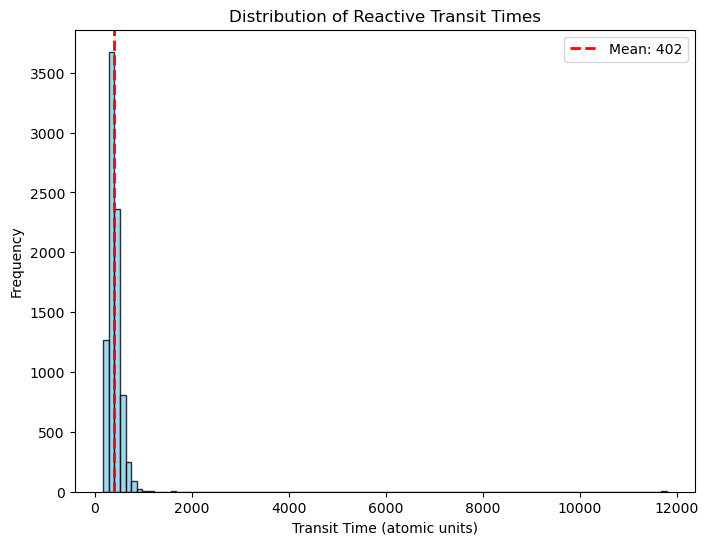

In [ ]:
# MTT plots

from matplotlib import pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(transit_times, bins=40, color='skyblue', edgecolor='black', alpha=0.8)
plt.title("Distribution of Reactive Transit Times")
plt.xlabel("Transit Time (atomic units)")
plt.ylabel("Frequency")
plt.axvline(mean_time, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_time:.0f}')
plt.legend()
plt.show()

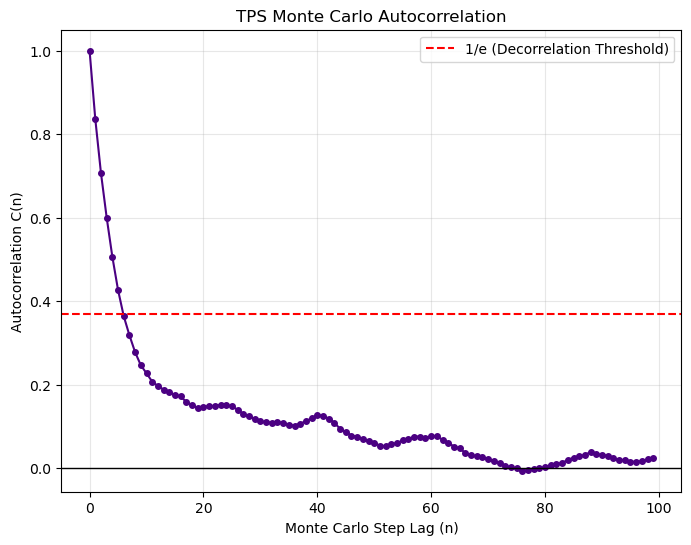

In [7]:
# Decorrelation plots

max_mc_lag = max_lag
plt.figure(figsize=(8, 6))
plt.plot(range(max_mc_lag), auto_correlation, marker='o', markersize=4, linestyle='-', color='indigo')
plt.axhline(0, color='black', linewidth=1)
plt.axhline(np.exp(-1), color='red', linestyle='dashed', label='1/e (Decorrelation Threshold)')

plt.title("TPS Monte Carlo Autocorrelation")
plt.xlabel("Monte Carlo Step Lag (n)")
plt.ylabel("Autocorrelation C(n)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

/opt/miniconda3/envs/local_basic/lib/python3.11/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/opt/miniconda3/envs/local_basic/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/local_basic/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


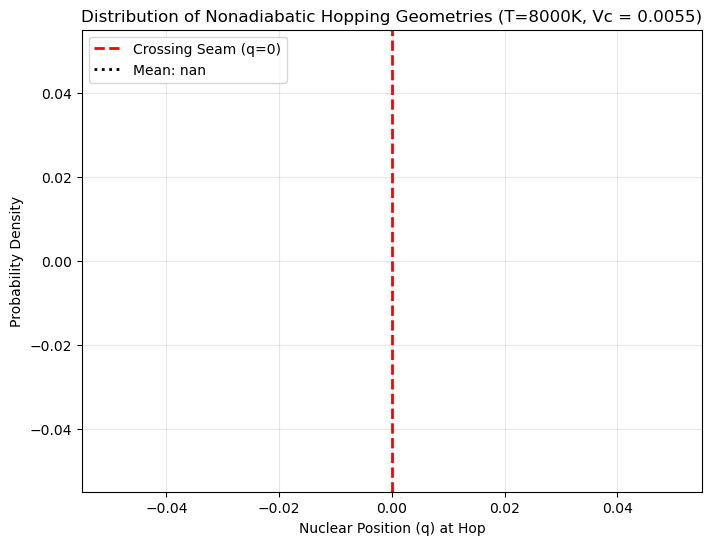

In [8]:
# Hopping geometry plots

plt.figure(figsize=(8, 6))
    
# We use density=True to normalize the histogram to a probability distribution
plt.hist(q_hops, bins=30, color='mediumpurple', edgecolor='black', alpha=0.7, density=True)

plt.title("Distribution of Nonadiabatic Hopping Geometries (T=8000K, Vc = 0.0055)")
plt.xlabel("Nuclear Position (q) at Hop")
plt.ylabel("Probability Density")

# Add a visual marker for the exact diabatic crossing seam
plt.axvline(0.0, color='red', linestyle='dashed', linewidth=2, label='Crossing Seam (q=0)')

# Calculate and plot the mean hopping position just to be thorough
mean_q = np.mean(q_hops)
plt.axvline(mean_q, color='black', linestyle='dotted', linewidth=2, label=f'Mean: {mean_q:.3f}')

plt.legend()
plt.grid(alpha=0.3)
plt.show()